In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

print(f"Pandas:     {pd.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Seaborn:    {sns.__version__}")
print(f"PyTorch:    {torch.__version__}")

Pandas:     2.3.3
NumPy:      2.0.1
Seaborn:    0.13.2
PyTorch:    2.5.1


In [22]:
# Load the CSV
df = pd.read_csv('energydata_complete.csv')

print(df.shape)         
print(df.dtypes)        
print(df.head(3))     
print(df.isnull().sum())

(19735, 29)
date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object
                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19

In [23]:

df['date'] = pd.to_datetime(df['date'])

df['Appliances'] = pd.to_numeric(df['Appliances'], errors='coerce')


df = df.set_index('date')


print(df.index.dtype)     
print(df['Appliances'].describe())

datetime64[ns]
count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64


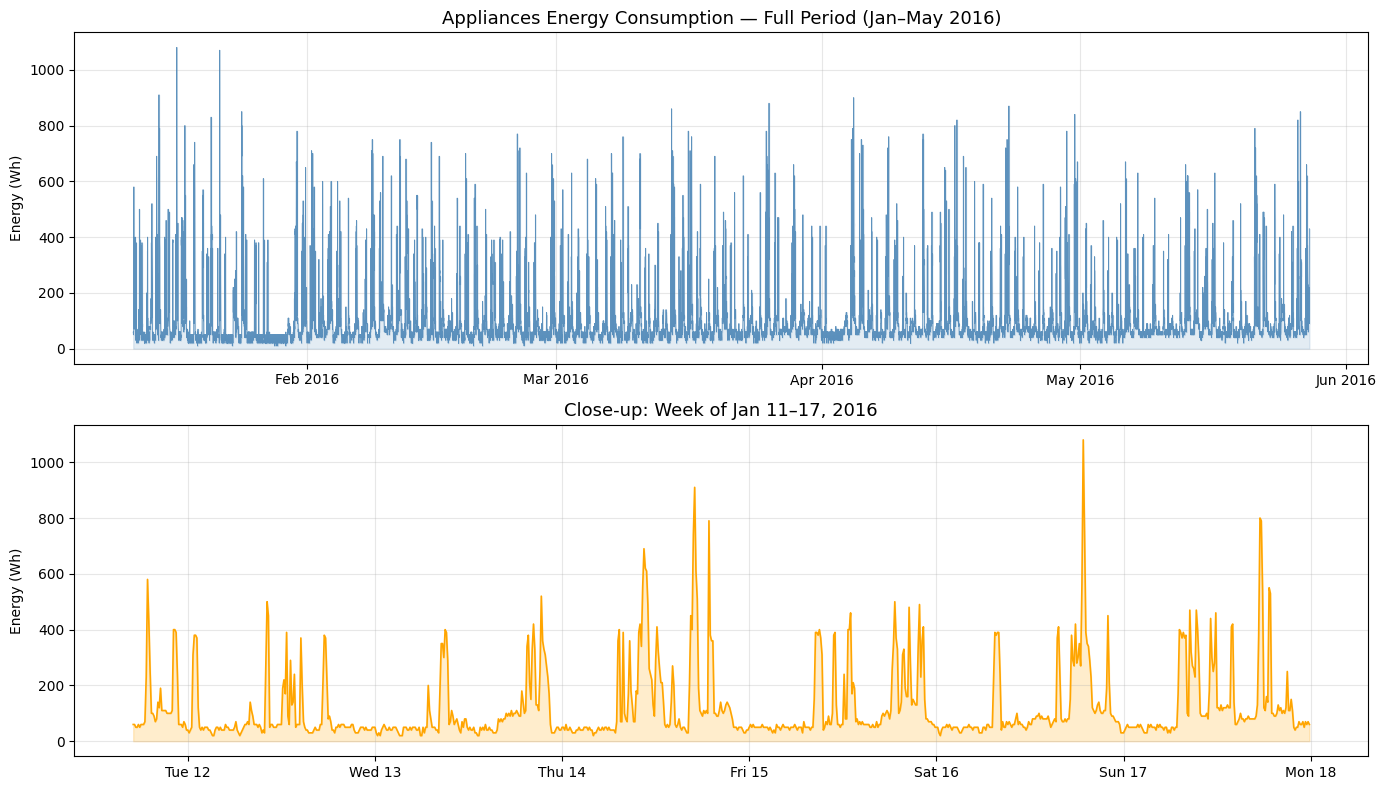

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]

ax1.plot(df.index, df['Appliances'], color='steelblue', linewidth=0.6, alpha=0.85)
ax1.fill_between(df.index, df['Appliances'], alpha=0.15, color='steelblue')

ax1.set_title('Appliances Energy Consumption — Full Period (Jan–May 2016)', fontsize=13)
ax1.set_ylabel('Energy (Wh)')

# Format x-axis to show month names
import matplotlib.dates as mdates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.grid(True, alpha=0.3)

week = df['2016-01-11':'2016-01-17']

ax2 = axes[1]
ax2.plot(week.index, week['Appliances'], color='orange', linewidth=1.2)
ax2.fill_between(week.index, week['Appliances'], alpha=0.2, color='orange')

ax2.set_title('Close-up: Week of Jan 11–17, 2016', fontsize=13)
ax2.set_ylabel('Energy (Wh)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:

week_df = df['2016-01-11':'2016-01-17'].copy()

week_df['hour'] = week_df.index.hour                    # 0–23
week_df['day']  = week_df.index.strftime('%a %m/%d')   # e.g. "Mon 01/11"

print(week_df[['hour', 'day', 'Appliances']].head(10))


                     hour        day  Appliances
date                                            
2016-01-11 17:00:00    17  Mon 01/11          60
2016-01-11 17:10:00    17  Mon 01/11          60
2016-01-11 17:20:00    17  Mon 01/11          50
2016-01-11 17:30:00    17  Mon 01/11          50
2016-01-11 17:40:00    17  Mon 01/11          60
2016-01-11 17:50:00    17  Mon 01/11          50
2016-01-11 18:00:00    18  Mon 01/11          60
2016-01-11 18:10:00    18  Mon 01/11          60
2016-01-11 18:20:00    18  Mon 01/11          60
2016-01-11 18:30:00    18  Mon 01/11          70


In [26]:
# Pivot into a 2D matrix: rows = hours, columns = days
# aggfunc='mean' averages the ~6 readings per hour
heatmap_data = week_df.pivot_table(
    values='Appliances',
    index='hour',
    columns='day',
    aggfunc='mean'
)

heatmap_data = heatmap_data[sorted(heatmap_data.columns,
    key=lambda x: pd.to_datetime(x.split()[1], format='%m/%d'))]

print(heatmap_data.shape)

(24, 7)


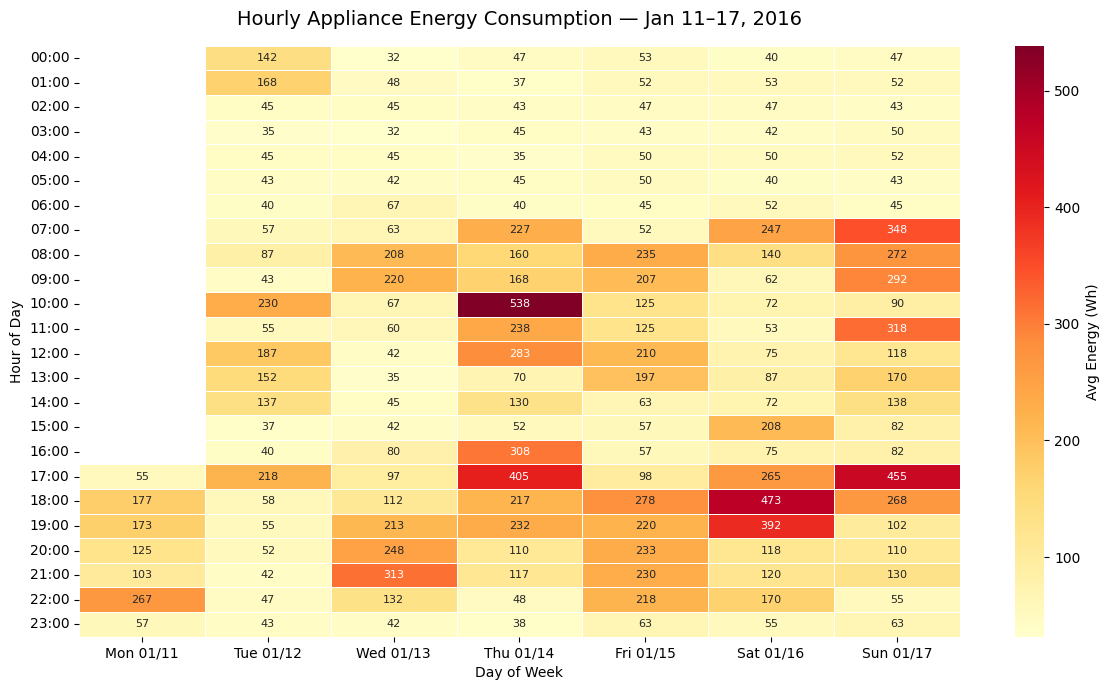

In [27]:
# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='YlOrRd',          # Yellow→Orange→Red, intuitive for energy
    linewidths=0.5,
    annot=True,             
    fmt='.0f',             
    annot_kws={'size': 8},
    cbar_kws={'label': 'Avg Energy (Wh)'}
)

ax.set_title('Hourly Appliance Energy Consumption — Jan 11–17, 2016', fontsize=14, pad=15)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour of Day')

# Make y-axis show "00:00" format
ax.set_yticklabels([f'{h:02d}:00' for h in heatmap_data.index], rotation=0)

plt.tight_layout()
plt.savefig('fig2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

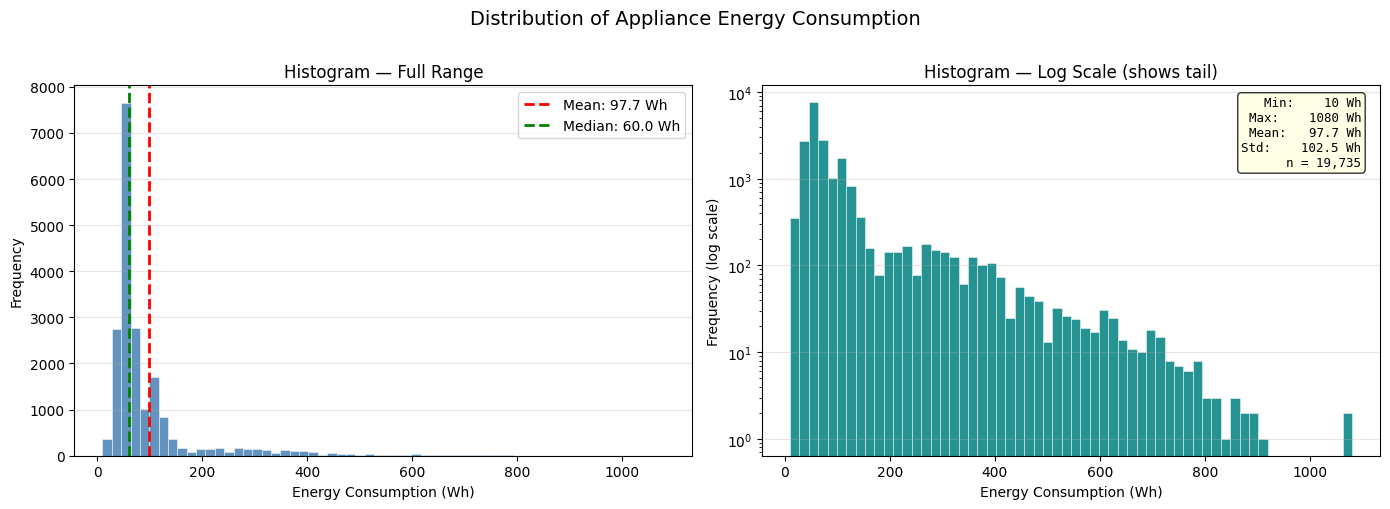

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Standard histogram ──────────────────────────────────────
ax1 = axes[0]
ax1.hist(df['Appliances'], bins=60, color='steelblue',
         edgecolor='white', linewidth=0.4, alpha=0.85)

# Add mean and median lines to understand skewness
mean_val   = df['Appliances'].mean()
median_val = df['Appliances'].median()

ax1.axvline(mean_val,   color='red',    linewidth=2, linestyle='--',
            label=f'Mean: {mean_val:.1f} Wh')
ax1.axvline(median_val, color='green',  linewidth=2, linestyle='--',
            label=f'Median: {median_val:.1f} Wh')

ax1.set_xlabel('Energy Consumption (Wh)')
ax1.set_ylabel('Frequency')
ax1.set_title('Histogram — Full Range')
ax1.legend()
ax1.grid(True, axis='y', alpha=0.3)

# ── Right: Log-scale (reveals tail behavior) ──────────────────────
ax2 = axes[1]
ax2.hist(df['Appliances'], bins=60, color='teal',
         edgecolor='white', linewidth=0.4, alpha=0.85, log=True)

ax2.set_xlabel('Energy Consumption (Wh)')
ax2.set_ylabel('Frequency (log scale)')
ax2.set_title('Histogram — Log Scale (shows tail)')
ax2.grid(True, axis='y', alpha=0.3)

# Add a summary stats box
stats = df['Appliances'].describe()
stats_text = (
    f"Min:    {stats['min']:.0f} Wh\n"
    f"Max:    {stats['max']:.0f} Wh\n"
    f"Mean:   {stats['mean']:.1f} Wh\n"
    f"Std:    {stats['std']:.1f} Wh\n"
    f"n = {len(df):,}"
)
ax2.text(0.97, 0.97, stats_text, transform=ax2.transAxes,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
         fontfamily='monospace', fontsize=9)

plt.suptitle('Distribution of Appliance Energy Consumption', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig3_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader

class EnergyDataset(Dataset):
    def __init__(self, dataframe, seq_len=24):
        # Normalize
        values = dataframe['Appliances'].values.astype('float32')
        self.mean = values.mean()
        self.std  = values.std()
        self.data = (values - self.mean) / self.std
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len]
        return torch.tensor(x).unsqueeze(-1), torch.tensor(y)

# Usage
dataset = EnergyDataset(df, seq_len=144)  # 144 steps = 24 hours at 10-min intervals
loader  = DataLoader(dataset, batch_size=32, shuffle=True)

x_batch, y_batch = next(iter(loader))
print(f"Input shape:  {x_batch.shape}")  # [32, 144, 1]
print(f"Target shape: {y_batch.shape}")  # [32]

Input shape:  torch.Size([32, 144, 1])
Target shape: torch.Size([32])


4. Construct NSM and Plot Energy vs NSM

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare (same as before)
df = pd.read_csv('energydata_complete.csv')
df['date'] = pd.to_datetime(df['date'])
df['Appliances'] = pd.to_numeric(df['Appliances'], errors='coerce')
df = df.set_index('date')

# ── Step 4a: Construct NSM ────────────────────────────────────────────────────
# Extract time components from the datetime index
df['hour']   = df.index.hour
df['minute'] = df.index.minute
df['second'] = df.index.second

# NSM formula: total seconds elapsed since midnight
df['NSM'] = df['hour'] * 3600 + df['minute'] * 60 + df['second']

# Verify: midnight = 0, noon = 43200, 11:50 PM = 85800
print(df[['hour', 'minute', 'NSM']].head(10))
print(f"\nNSM range: {df['NSM'].min()} to {df['NSM'].max()} seconds")

                     hour  minute    NSM
date                                    
2016-01-11 17:00:00    17       0  61200
2016-01-11 17:10:00    17      10  61800
2016-01-11 17:20:00    17      20  62400
2016-01-11 17:30:00    17      30  63000
2016-01-11 17:40:00    17      40  63600
2016-01-11 17:50:00    17      50  64200
2016-01-11 18:00:00    18       0  64800
2016-01-11 18:10:00    18      10  65400
2016-01-11 18:20:00    18      20  66000
2016-01-11 18:30:00    18      30  66600

NSM range: 0 to 85800 seconds


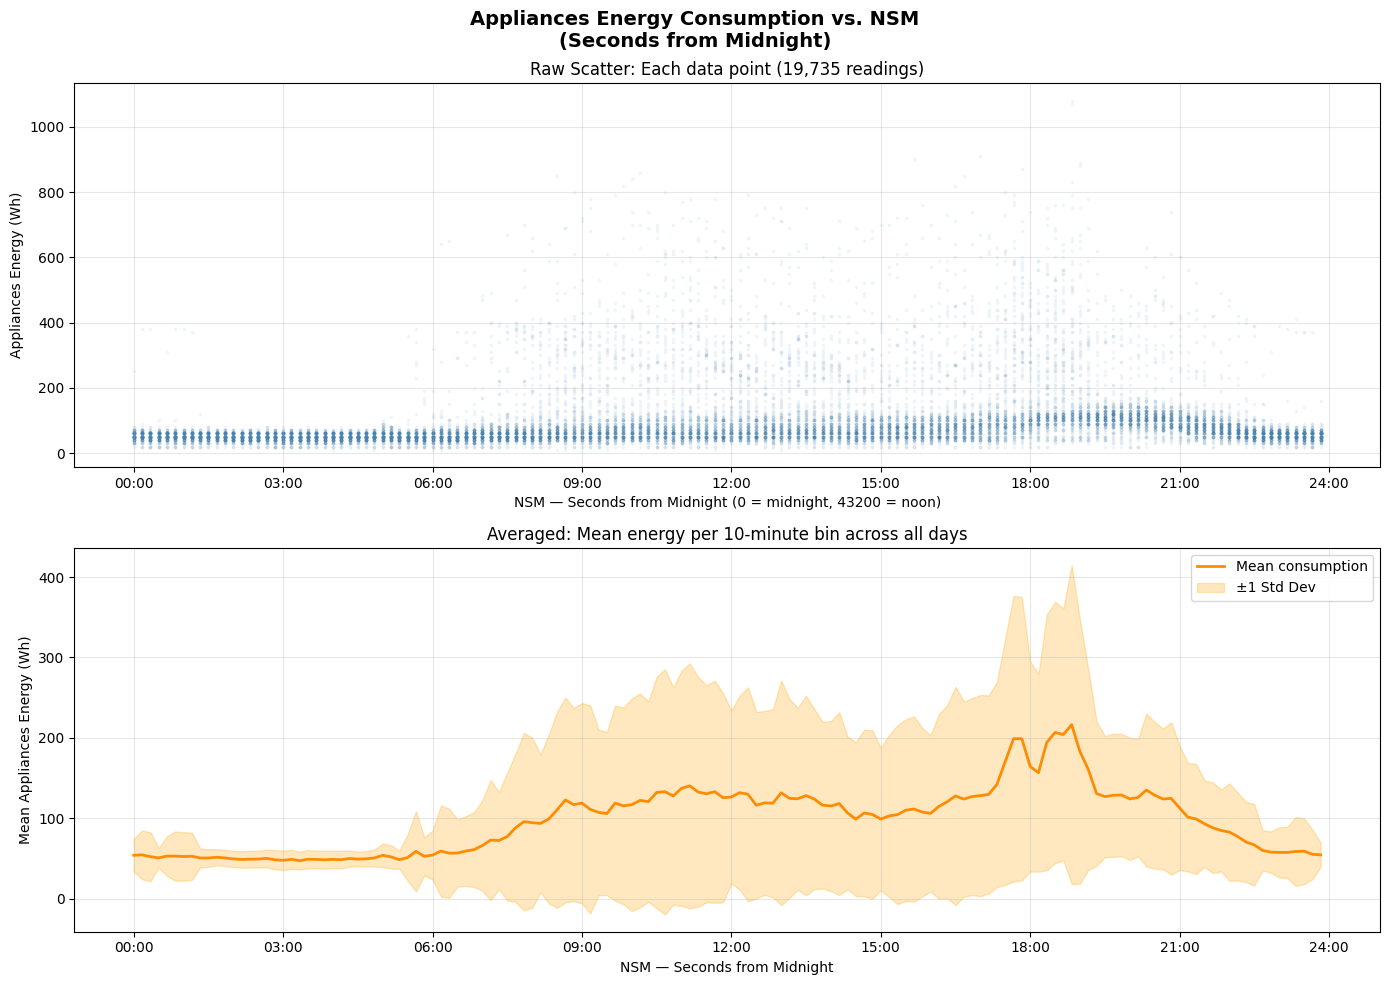

In [31]:
#Plot Energy vs NSM ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Appliances Energy Consumption vs. NSM\n(Seconds from Midnight)',
             fontsize=14, fontweight='bold')

# Scatter plot (all data points) ───────────────────────
ax1 = axes[0]
ax1.scatter(df['NSM'], df['Appliances'],
            alpha=0.05,     
            s=3,              
            color='steelblue')

ax1.set_xlabel('NSM — Seconds from Midnight (0 = midnight, 43200 = noon)')
ax1.set_ylabel('Appliances Energy (Wh)')
ax1.set_title('Raw Scatter: Each data point (19,735 readings)')
ax1.grid(True, alpha=0.3)

# Add readable x-axis labels (convert seconds to HH:MM)
tick_positions = [i * 3600 for i in range(0, 25, 3)]   # every 3 hours
tick_labels    = [f'{i:02d}:00' for i in range(0, 25, 3)]
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels)

# Mean energy per NSM bin (10-min bins = 600 sec)
ax2 = axes[1]

# Bin NSM into 10-minute buckets (600 seconds each) and compute mean
df['NSM_bin'] = (df['NSM'] // 600) * 600   # floor to nearest 600 seconds
avg_by_nsm = df.groupby('NSM_bin')['Appliances'].mean()
std_by_nsm = df.groupby('NSM_bin')['Appliances'].std()

ax2.plot(avg_by_nsm.index, avg_by_nsm.values,
         color='darkorange', linewidth=2, label='Mean consumption')
ax2.fill_between(avg_by_nsm.index,
                 avg_by_nsm - std_by_nsm,
                 avg_by_nsm + std_by_nsm,
                 alpha=0.25, color='orange', label='±1 Std Dev')

ax2.set_xlabel('NSM — Seconds from Midnight')
ax2.set_ylabel('Mean Appliances Energy (Wh)')
ax2.set_title('Averaged: Mean energy per 10-minute bin across all days')
ax2.set_xticks(tick_positions)
ax2.set_xticklabels(tick_labels)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('fig4_energy_vs_nsm.png', dpi=150, bbox_inches='tight')
plt.show()

Task 5: Plot Energy vs Press_mm_Hg

In [32]:
# Basic inspection of the pressure variable ───────────────────────
print(df['Press_mm_hg'].describe())
print(f"\nCorrelation with Appliances: {df['Press_mm_hg'].corr(df['Appliances']):.4f}")


count    19735.000000
mean       755.522602
std          7.399441
min        729.300000
25%        750.933333
50%        756.100000
75%        760.933333
max        772.300000
Name: Press_mm_hg, dtype: float64

Correlation with Appliances: -0.0349


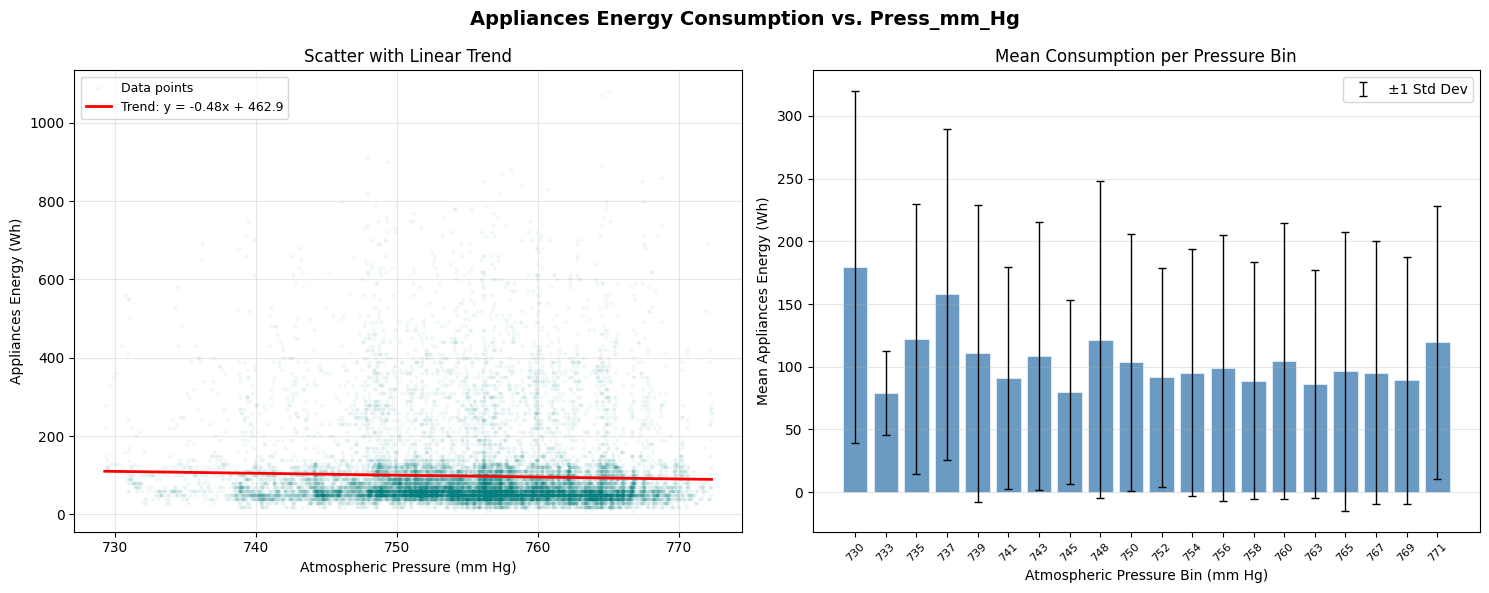

In [33]:
# ── Plot Energy vs Pressure ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Appliances Energy Consumption vs. Press_mm_Hg', fontsize=14, fontweight='bold')

# ── Scatter plot with regression line ───────────────────────
ax1 = axes[0]

# Scatter (with transparency for dense overlap)
ax1.scatter(df['Press_mm_hg'], df['Appliances'],
            alpha=0.04, s=4, color='teal', label='Data points')

# Fit and overlay a linear regression line manually using numpy
x = df['Press_mm_hg'].dropna().values
y = df.loc[df['Press_mm_hg'].notna(), 'Appliances'].values
coeffs = np.polyfit(x, y, 1)            # degree-1 polynomial = line
poly   = np.poly1d(coeffs)
x_line = np.linspace(x.min(), x.max(), 100)
ax1.plot(x_line, poly(x_line), color='red', linewidth=2,
         label=f'Trend: y = {coeffs[0]:.2f}x + {coeffs[1]:.1f}')

ax1.set_xlabel('Atmospheric Pressure (mm Hg)')
ax1.set_ylabel('Appliances Energy (Wh)')
ax1.set_title('Scatter with Linear Trend')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Right: Binned average — cleaner view of the relationship ──────
ax2 = axes[1]

# Bin pressure into 2 mmHg intervals
df['Press_bin'] = pd.cut(df['Press_mm_hg'], bins=20)
avg_by_press = df.groupby('Press_bin', observed=True)['Appliances'].agg(['mean', 'std', 'count'])
bin_centers  = avg_by_press.index.map(lambda x: x.mid)

ax2.bar(range(len(avg_by_press)), avg_by_press['mean'],
        color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.5)
ax2.errorbar(range(len(avg_by_press)), avg_by_press['mean'],
             yerr=avg_by_press['std'], fmt='none', color='black',
             capsize=3, linewidth=1, label='±1 Std Dev')

# Rotate and label x-axis with pressure ranges
ax2.set_xticks(range(len(avg_by_press)))
ax2.set_xticklabels([f'{c:.0f}' for c in bin_centers], rotation=45, fontsize=8)
ax2.set_xlabel('Atmospheric Pressure Bin (mm Hg)')
ax2.set_ylabel('Mean Appliances Energy (Wh)')
ax2.set_title('Mean Consumption per Pressure Bin')
ax2.legend()
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_energy_vs_pressure.png', dpi=150, bbox_inches='tight')
plt.show()

Task 6: Why NSM and Press_mm_Hg are Major Contributing Factors

In [34]:
# Compute correlation of ALL features with Appliances ──────────────

# Make sure NSM is in the dataframe
df['NSM'] = df.index.hour * 3600 + df.index.minute * 60 + df.index.second

# Select numeric columns only (drop lights, rv1, rv2 which are noise)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Appliances')   # we correlate everything WITH Appliances

correlations = df[numeric_cols + ['Appliances']].corr()['Appliances'].drop('Appliances')
correlations = correlations.sort_values(key=abs, ascending=False)

print("Feature correlations with Appliances (sorted by absolute value):")
print(correlations.to_string())

Feature correlations with Appliances (sorted by absolute value):
NSM_bin        0.217152
NSM            0.217152
hour           0.216792
lights         0.197278
RH_out        -0.152282
T2             0.120073
T6             0.117638
T_out          0.099155
RH_8          -0.094039
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
RH_6          -0.083178
RH_2          -0.060465
RH_7          -0.055642
T1             0.055447
RH_9          -0.051462
T4             0.040281
T8             0.039572
RH_3           0.036292
Press_mm_hg   -0.034885
T7             0.025801
T5             0.019760
RH_4           0.016965
Tdewpoint      0.015353
minute         0.013216
rv2           -0.011145
rv1           -0.011145
T9             0.010010
RH_5           0.006955
Visibility     0.000230
second              NaN


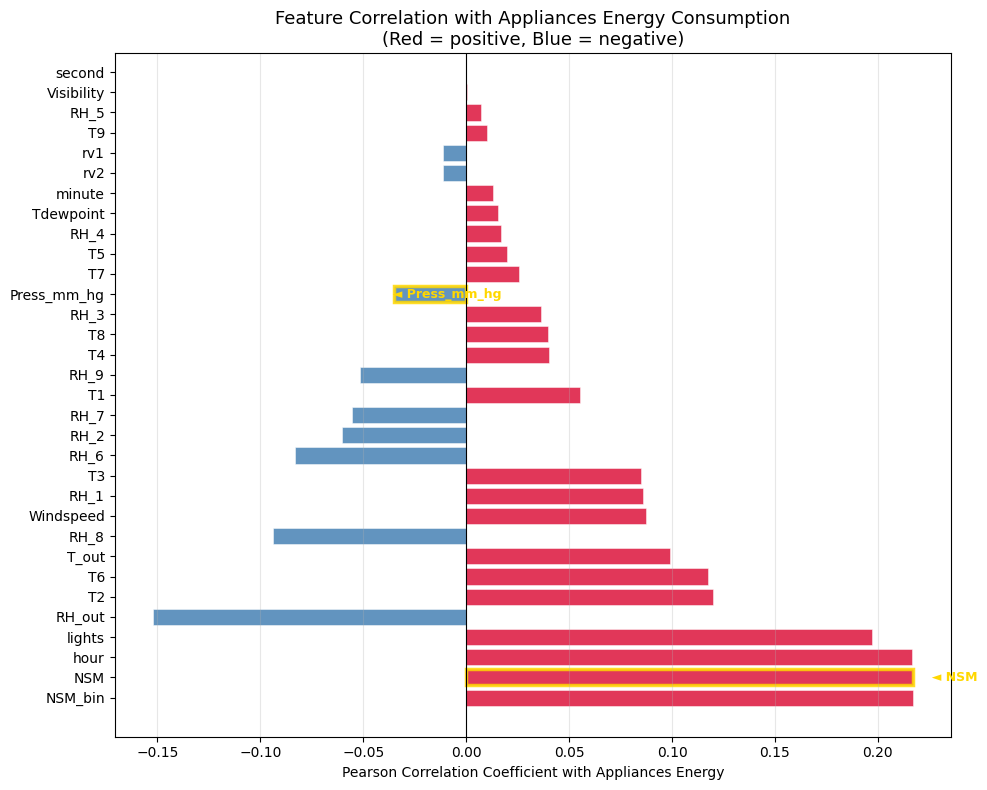

In [35]:
# ──Plot the correlation bar chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['crimson' if v > 0 else 'steelblue' for v in correlations.values]
bars = ax.barh(correlations.index, correlations.values,
               color=colors, alpha=0.85, edgecolor='white', linewidth=0.4)

# Highlight NSM and Press_mm_hg specifically
for i, (feat, val) in enumerate(correlations.items()):
    if feat in ['NSM', 'Press_mm_hg']:
        bars[i].set_edgecolor('gold')
        bars[i].set_linewidth(2.5)
        ax.text(val + (0.005 if val > 0 else -0.005), i,
                f'  ◄ {feat}', va='center', fontsize=9,
                color='gold', fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation Coefficient with Appliances Energy')
ax.set_title('Feature Correlation with Appliances Energy Consumption\n'
             '(Red = positive, Blue = negative)', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Scatter matrix for just the top features ────────────────────────
top_features = ['Appliances', 'NSM', 'Press_mm_hg', 'T1', 'RH_1', 'T_out']

fig = plt.figure(figsize=(12, 10))
pd.plotting.scatter_matrix(df[top_features],
                           alpha=0.05, figsize=(12, 10),
                           diagonal='hist',
                           color='steelblue')
plt.suptitle('Scatter Matrix: Top Features vs Appliances', y=1.01, fontsize=13)
plt.savefig('fig6b_scatter_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

<Figure size 1200x1000 with 0 Axes>